In [29]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_raw.nc")
print(ds)

<xarray.Dataset> Size: 14kB
Dimensions:                      (region_id: 237, period: 6)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U26 624B '1981–1990' ... '2020–202...
Data variables:
    record_breaking_probability  (region_id, period) float64 11kB ...


In [3]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_fixed_params.nc")
print(ds)

<xarray.Dataset> Size: 12kB
Dimensions:                      (region_id: 237, period: 5)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U9 180B '1981-1990' ... '2020-2024'
Data variables:
    record_breaking_probability  (region_id, period) float64 9kB ...


In [4]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_fixed_record.nc")
print(ds)

<xarray.Dataset> Size: 12kB
Dimensions:                      (region_id: 237, period: 5)
Coordinates:
  * region_id                    (region_id) int64 2kB 0 1 2 3 ... 234 235 236
  * period                       (period) <U9 180B '1981-1990' ... '2020-2024'
Data variables:
    record_breaking_probability  (region_id, period) float64 9kB ...


Selected regions: [ 30 161 199  46   9  57]


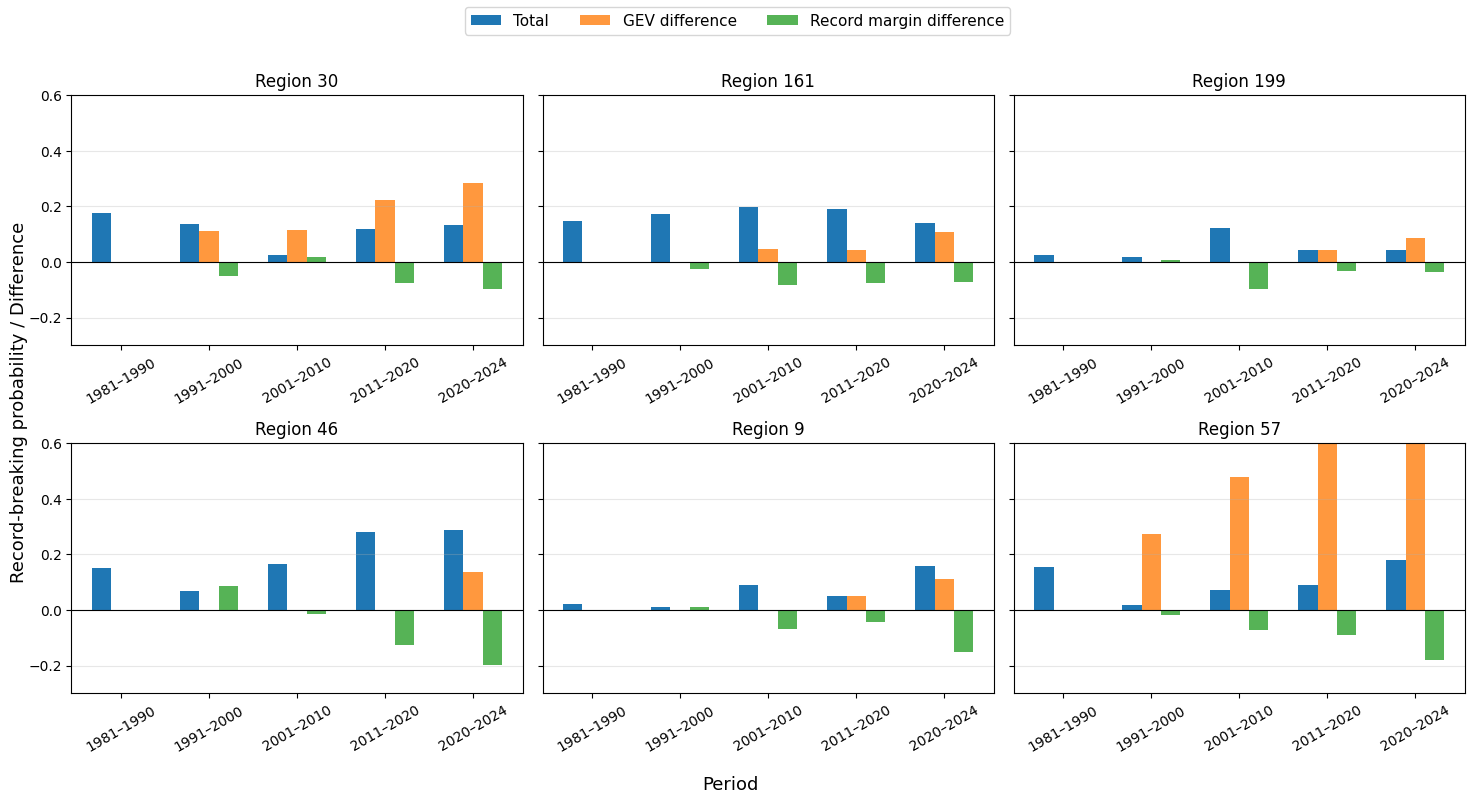

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# =========================================================
# 输入文件
# =========================================================
file1 = "record_breaking_probability_raw.nc"
file2 = "record_breaking_probability_fixed_record.nc"
file3 = "record_breaking_probability_fixed_params.nc"

labels = [
    "Total",
    "GEV difference",
    "Record margin difference",
]

# =========================================================
# 读取数据（仅前5个period）
# =========================================================
ds1 = xr.open_dataset(file1).isel(period=slice(0, 5))
ds2 = xr.open_dataset(file2).isel(period=slice(0, 5))
ds3 = xr.open_dataset(file3).isel(period=slice(0, 5))

periods = ds1.period.values.astype(str)
region_ids = ds1.region_id.values

# =========================================================
# 随机选择6个region
# =========================================================
np.random.seed(41)

selected_regions = np.random.choice(
    region_ids,
    size=6,
    replace=False
)

print("Selected regions:", selected_regions)

# =========================================================
# 绘图
# =========================================================
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8),
    sharey=True
)

axes = axes.flatten()

bar_width = 0.22
x = np.arange(len(periods))

for ax, region in zip(axes, selected_regions):

    # -------------------------------
    # 读取数据
    # -------------------------------
    total = ds1.record_breaking_probability.sel(region_id=region).values

    gev_diff = (
        ds2.record_breaking_probability.sel(region_id=region).values
        - total
    )

    record_diff = (
        ds3.record_breaking_probability.sel(region_id=region).values
        - total
    )

    # -------------------------------
    # 画柱状图
    # -------------------------------
    ax.bar(
        x - bar_width,
        total,
        width=bar_width,
        label=labels[0]
    )

    ax.bar(
        x,
        gev_diff,
        width=bar_width,
        label=labels[1],
        alpha=0.8
    )

    ax.bar(
        x + bar_width,
        record_diff,
        width=bar_width,
        label=labels[2],
        alpha=0.8
    )

    # 零线
    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.set_title(f"Region {region}", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(periods, rotation=30)

    ax.set_ylim(-0.3, 0.6)

    ax.grid(axis="y", alpha=0.3)

# =========================================================
# 公共图例
# =========================================================
handles, legend_labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    ncol=3,
    fontsize=11
)

fig.supxlabel(
    "Period",
    fontsize=13
)

fig.supylabel(
    "Record-breaking probability / Difference",
    fontsize=13
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    "compare_probability_barplots.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
import numpy as np
import xarray as xr
from scipy.stats import genextreme as gev

# =========================================================
# 读取数据
# =========================================================
ecmwf_ds = xr.open_dataset("IFS_t2m_hottest_month.nc")
rl_ds = xr.open_dataset("Berkeley_hottest_month_by_region_revised_by_ERA5.nc")

t2m_ifs_all = ecmwf_ds["t2m_hottest_month"]
t2m_berkeley_all = rl_ds["t2m_hottest"]

n_regions = 237

# =========================================================
# 时间段设置
# =========================================================
# 新增2的逻辑：
# P1 (1981-1990) -> 1980
# P2 (1991-2000) -> 1980
# P3 (2001-2010) -> 1990
# P4 (2011-2020) -> 2000
# P5 (2020-2024) -> 2010 (对应原第5个时段)
# P6 (2020-2024_current) -> 2010 (对应原第6个时段，这里延续2010的处理方法)
time_periods = [
    {"start": 1981, "end": 1990, "max_until": 1990, "max_until_fixed": 1980, "label": "1981-1990"},
    {"start": 1991, "end": 2000, "max_until": 2000, "max_until_fixed": 1980, "label": "1991-2000"},
    {"start": 2001, "end": 2010, "max_until": 2010, "max_until_fixed": 1990, "label": "2001-2010"},
    {"start": 2011, "end": 2020, "max_until": 2020, "max_until_fixed": 2000, "label": "2011-2020"},
    {"start": 2020, "end": 2024, "max_until": 2025, "max_until_fixed": 2010, "label": "2020-2024"},
    # {"start": 2020, "end": 2024, "max_until": 2025, "max_until_fixed": 2010, "label": "2020-2024_current_record"},
]

# =========================================================
# 工具函数
# =========================================================
def get_max_before_year(ds, end_year):
    return (
        ds.sel(year=slice(1940, end_year))
        .t2m_hottest
        .max(dim="year")
    )

# =========================================================
# 计算概率 (定义三个不同的结果矩阵)
# =========================================================
prob_map_raw = np.full((n_regions, len(time_periods)), np.nan)      # 原始概率
prob_map_add1 = np.full((n_regions, len(time_periods)), np.nan)     # 新增1：阈值为该时间段最后一年的纪录
prob_map_add2 = np.full((n_regions, len(time_periods)), np.nan)     # 新增2：固定的年代际历史纪录

for i, period in enumerate(time_periods):

    print(f"Processing {period['label']}")

    # IFS数据
    t2m_ifs = t2m_ifs_all.sel(year=slice(period["start"], period["end"]))

    # Berkeley数据
    t2m_obs = t2m_berkeley_all.sel(year=slice(period["start"], period["end"]))

    # Bias correction
    t2m_corrected = (
        t2m_ifs
        - t2m_ifs.mean(dim="year")
        + t2m_obs.mean(dim="year")
    )

    # 计算三种不同定义的历史纪录阈值
    max_record_raw = get_max_before_year(rl_ds, period["start"]-1)
    max_record_add1 = get_max_before_year(rl_ds, period["start"]-11)  # 新增1：上一个时间段无记录发生
    max_record_add2 = get_max_before_year(rl_ds, period["max_until"]) # 新增2：仅仅考虑GEV变化的作用

    # reshape: (year, realization, region)
    values = (
        t2m_corrected.values
        .transpose(0, 2, 1)
        .reshape(-1, n_regions)
    )

    for r in range(n_regions):

        series = values[:, r]
        series = series[~np.isnan(series)]

        if len(series) < 30:
            continue

        try:
            # 拟合 GEV 分布参数
            c, loc, scale = gev.fit(series)

            # 提取 3 个不同的阈值
            threshold_raw = max_record_raw.sel(region_id=r).item()
            threshold_add1 = max_record_add1.sel(region_id=r).item()
            threshold_add2 = max_record_add2.sel(region_id=r).item()

            # 计算原始概率
            prob_map_raw[r, i] = 1 - gev.cdf(
                threshold_raw, c, loc=loc, scale=scale
            )

            # 计算新增1的概率
            prob_map_add1[r, i] = 1 - gev.cdf(
                threshold_add1, c, loc=loc, scale=scale
            )

            # 计算新增2的概率
            prob_map_add2[r, i] = 1 - gev.cdf(
                threshold_add2, c, loc=loc, scale=scale
            )

        except Exception:
            pass

# =========================================================
# 保存结果
# =========================================================
output = xr.Dataset(
    {
        "record_breaking_probability_raw": (
            ("region_id", "period"),
            prob_map_raw
        ),
        "record_breaking_probability_end_year": (
            ("region_id", "period"),
            prob_map_add1
        ),
        "record_breaking_probability_fixed_period": (
            ("region_id", "period"),
            prob_map_add2
        )
    },
    coords={
        "region_id": np.arange(n_regions),
        "period": [p["label"] for p in time_periods],
    },
)

output.to_netcdf("record_breaking_probability_combined.nc")

print("Saved: record_breaking_probability_combined.nc")

Processing 1981-1990
Processing 1991-2000
Processing 2001-2010
Processing 2011-2020
Processing 2020-2024
Saved: record_breaking_probability_combined.nc


In [32]:
import xarray as xr

ds = xr.open_dataset("record_breaking_probability_combined.nc")
print(ds)

<xarray.Dataset> Size: 31kB
Dimensions:                                   (region_id: 237, period: 5)
Coordinates:
  * region_id                                 (region_id) int64 2kB 0 1 ... 236
  * period                                    (period) <U9 180B '1981-1990' ....
Data variables:
    record_breaking_probability_raw           (region_id, period) float64 9kB ...
    record_breaking_probability_end_year      (region_id, period) float64 9kB ...
    record_breaking_probability_fixed_period  (region_id, period) float64 9kB ...


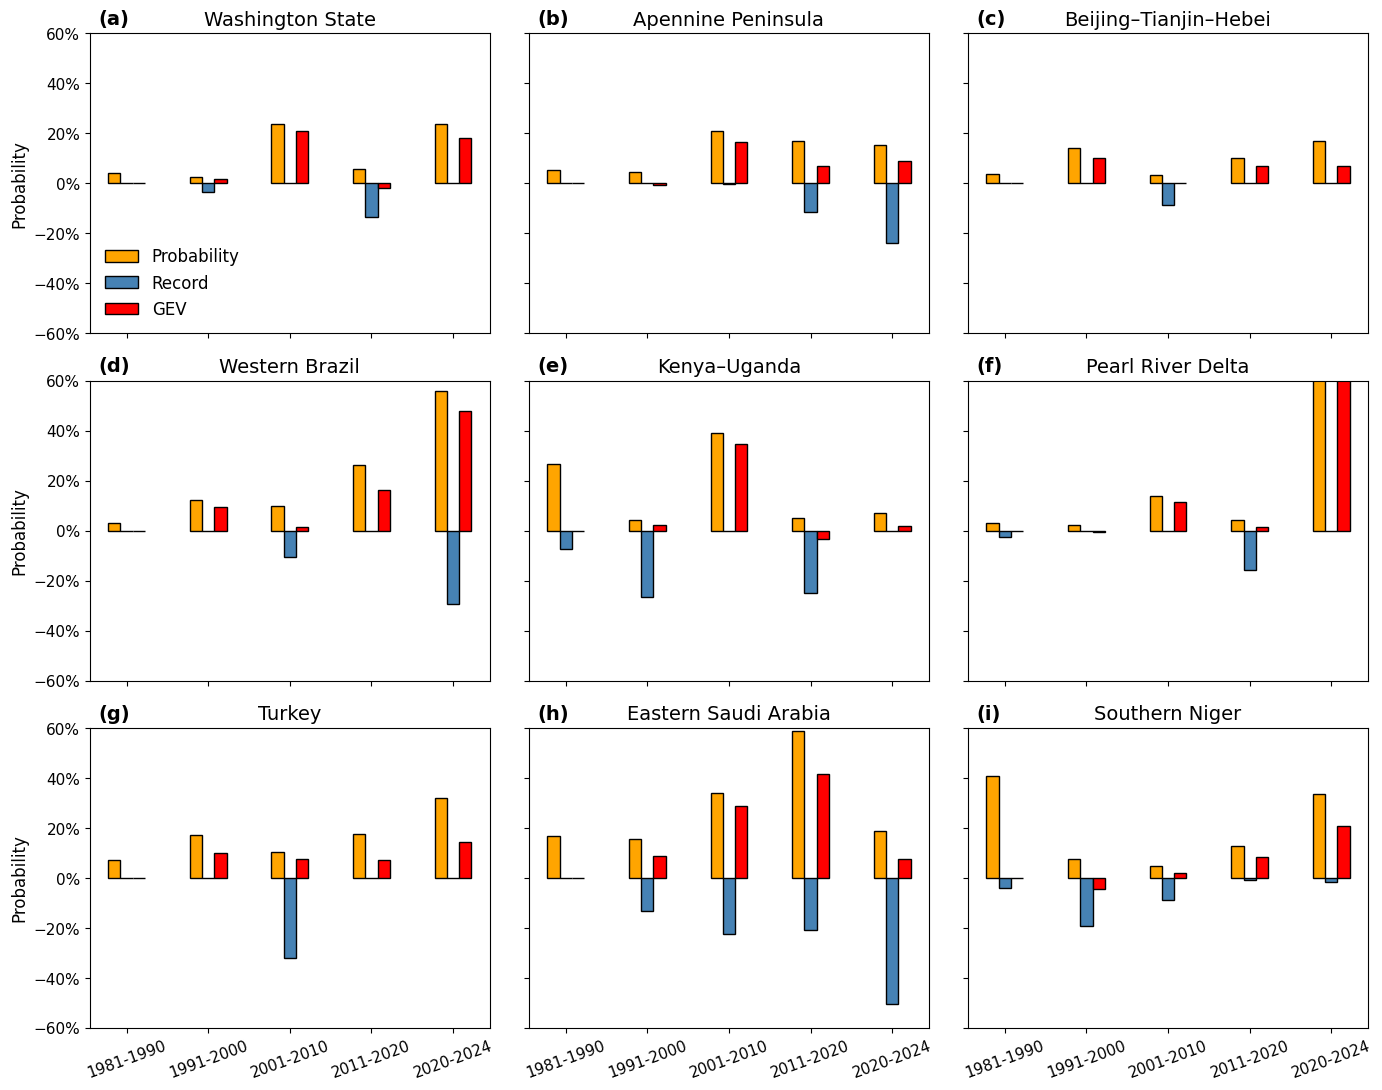

In [18]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# =========================================================
# 读取数据
# =========================================================
ds = xr.open_dataset("record_breaking_probability_combined.nc").isel(period=slice(0, 5))

# =========================================================
# 提取变量
# =========================================================
prob_raw = ds["record_breaking_probability_raw"].values
prob_end = ds["record_breaking_probability_end_year"].values
prob_fixed = ds["record_breaking_probability_fixed_period"].values

# =========================================================
# 构造贡献项
# =========================================================
prob_fixed_shifted = np.empty_like(prob_fixed)
prob_fixed_shifted[:, 1:] = prob_fixed[:, :-1]
prob_fixed_shifted[:, 0] = prob_raw[:, 0]

prob_diff_end = prob_raw - prob_end
prob_diff_fixed = prob_raw - prob_fixed_shifted

# =========================================================
# 选择区域（修改为你的9个区域）
# =========================================================
selected_regions = np.array([
    19, 204, 149,
    33, 228, 157,
    128, 69, 79          # <-- 修改成你的另外三个region ID
])

region_names = [
    "Washington State",
    "Apennine Peninsula",
    "Beijing–Tianjin–Hebei",
    "Western Brazil",
    "Kenya–Uganda",
    "Pearl River Delta",
    "Turkey",
    "Eastern Saudi Arabia",
    "Southern Niger"
]

period_labels = ds["period"].values

# =========================================================
# 绘图
# =========================================================
fig, axes = plt.subplots(
    3, 3,
    figsize=(14, 11),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

x = np.arange(len(period_labels))
width = 0.15

for i, (ax, region) in enumerate(zip(axes, selected_regions)):

    # =====================================================
    # 三组柱
    # =====================================================
    ax.bar(
        x - width,
        prob_raw[region],
        width,
        color="orange",
        edgecolor="black",
        label="Probability"
    )

    ax.bar(
        x,
        prob_diff_end[region],
        width,
        color="steelblue",
        edgecolor="black",
        label="Record"
    )

    ax.bar(
        x + width,
        prob_diff_fixed[region],
        width,
        color="red",
        edgecolor="black",
        label="GEV"
    )

    # =====================================================
    # 标题与子图序号 (a) 到 (i)
    # =====================================================
    ax.set_title(region_names[i], fontsize=14)
    
    # 生成字母标签：i=0 -> (a), i=1 -> (b) ...
    sub_label = f"({chr(97 + i)})"
    
    # 将序号放置在子图坐标系的左上角内部 (0.02, 0.93)
    ax.text(
        0.02, 1.08, 
        sub_label, 
        transform=ax.transAxes, 
        fontsize=14, 
        fontweight="bold", 
        va="top", 
        ha="left"
    )

    # =====================================================
    # 坐标轴
    # =====================================================
    ax.set_ylim(-0.6, 0.6)

    ax.set_xticks(x)

    # 只有最后一行显示x标签
    if i >= 6:
        ax.set_xticklabels(period_labels, rotation=20)
    else:
        ax.set_xticklabels([])

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))

    ax.tick_params(axis='both', labelsize=11)

    # 第一列显示y轴标题
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=12)

# =========================================================
# 图例（仅保留一份）
# =========================================================
axes[0].legend(
    fontsize=12,
    loc="lower left",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "Fig_selected_regions_timeseries_3bars_9regions.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

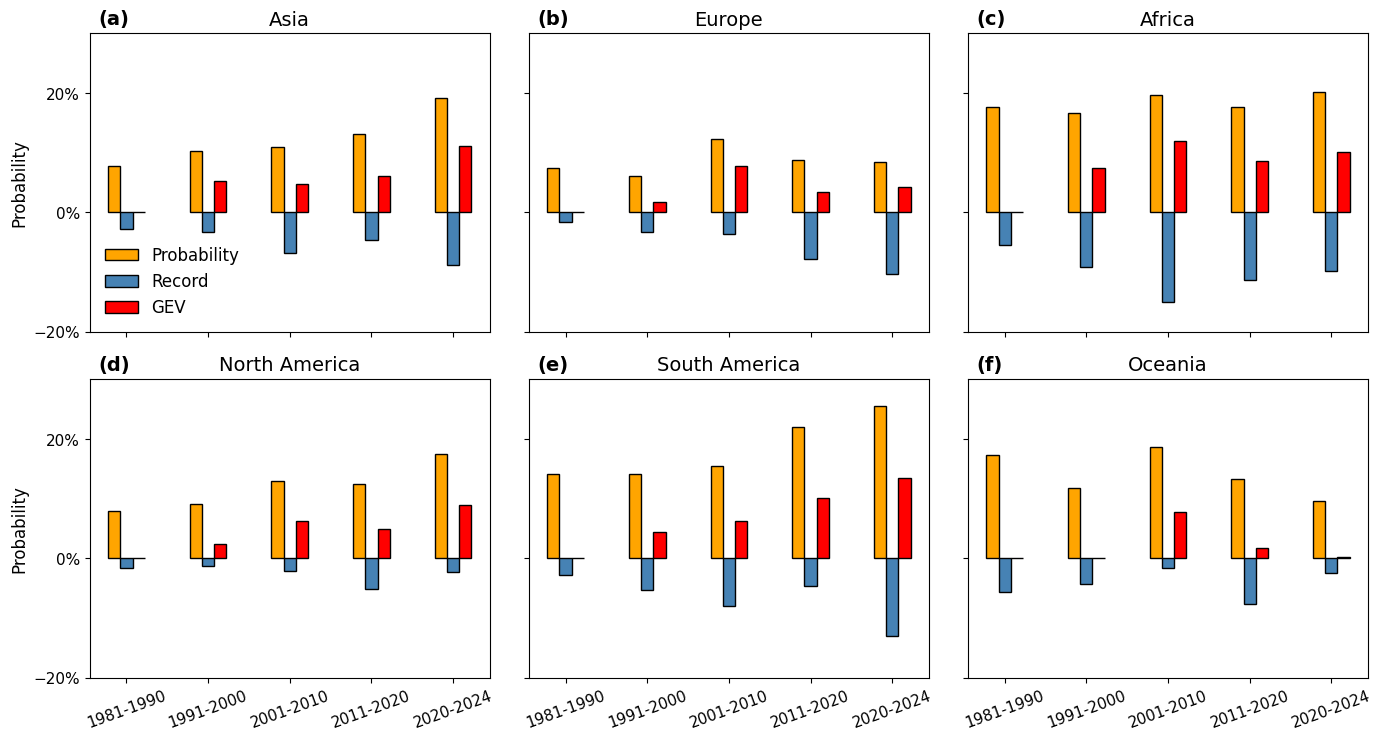

In [25]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# =========================================================
# 读取数据
# =========================================================
ds = xr.open_dataset("record_breaking_probability_combined.nc").isel(period=slice(0, 5))

# =========================================================
# 提取变量
# =========================================================
prob_raw = ds["record_breaking_probability_raw"].values
prob_end = ds["record_breaking_probability_end_year"].values
prob_fixed = ds["record_breaking_probability_fixed_period"].values

# =========================================================
# 构造贡献项
# =========================================================
prob_fixed_shifted = np.empty_like(prob_fixed)
prob_fixed_shifted[:, 1:] = prob_fixed[:, :-1]
prob_fixed_shifted[:, 0] = prob_raw[:, 0]

prob_diff_end = prob_raw - prob_end
prob_diff_fixed = prob_raw - prob_fixed_shifted

# =========================================================
# 大洲 ID 映射字典
# =========================================================
continents = {
    "Asia": [70,108,109,110,111,112,113,114,115,116,117,118,119,120,121,
             122,123,124,125,126,127,130,133,135,136,137,138,139,140,141,
             142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,
             157,206,207,208,209,210,211,212,213,214,215,216,217,229,230,
             231,235,236],

    "Europe": [102,103,104,105,106,107,128,129,131,134,197,198,199,
               200,201,202,203,204,205,234],

    "Africa": [52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,
               69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,
               87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,132,
               225,226,227,228],

    "North America": list(range(0,32)) + [218,219,220,221,222,223,224,232],
    "South America": list(range(32,52)) + [191,192,193,194,195,196,233],
    "Oceania": [158,159,160,161,162,163,164,165,166,167,168,169]
}

# =========================================================
# 准备绘图所需的大洲平均数据
# =========================================================
plot_names = []
plot_raw_data = []
plot_diff_end_data = []
plot_diff_fixed_data = []

for name, ids in continents.items():
    plot_names.append(name)
    plot_raw_data.append(np.mean(prob_raw[ids, :], axis=0))
    plot_diff_end_data.append(np.mean(prob_diff_end[ids, :], axis=0))
    plot_diff_fixed_data.append(np.mean(prob_diff_fixed[ids, :], axis=0))

period_labels = ds["period"].values

# =========================================================
# 绘图（修改为 2行 3列，调整了 figsize 比例）
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 7.5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

x = np.arange(len(period_labels))
width = 0.15 

for i, ax in enumerate(axes):

    # =====================================================
    # 三组柱
    # =====================================================
    ax.bar(
        x - width,
        plot_raw_data[i],
        width,
        color="orange",
        edgecolor="black",
        label="Probability"
    )

    ax.bar(
        x,
        plot_diff_end_data[i],
        width,
        color="steelblue",
        edgecolor="black",
        label="Record"
    )

    ax.bar(
        x + width,
        plot_diff_fixed_data[i],
        width,
        color="red",
        edgecolor="black",
        label="GEV"
    )

    # =====================================================
    # 标题与子图序号 (a) 到 (f)
    # =====================================================
    ax.set_title(plot_names[i], fontsize=14)
    
    sub_label = f"({chr(97 + i)})"
    
    ax.text(
        0.02, 1.08, 
        sub_label, 
        transform=ax.transAxes, 
        fontsize=14, 
        fontweight="bold", 
        va="top", 
        ha="left"
    )

    # =====================================================
    # 坐标轴设置
    # =====================================================
    ax.set_ylim(-0.2, 0.3)
    ax.set_xticks(x)

    # 只有第二行（索引 3, 4, 5）显示 x 轴标签
    if i >= 3:
        ax.set_xticklabels(period_labels, rotation=20)
    else:
        ax.set_xticklabels([])

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.tick_params(axis='both', labelsize=11)

    # 只有第一列（索引 0 和 3）显示 y 轴标题
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=12)

# =========================================================
# 图例（仅在左上角第一个大洲子图显示）
# =========================================================
axes[0].legend(
    fontsize=12,
    loc="lower left",
    frameon=False
)

plt.tight_layout()

# 保存高质量 PDF
plt.savefig(
    "Fig_continents_timeseries_3bars.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

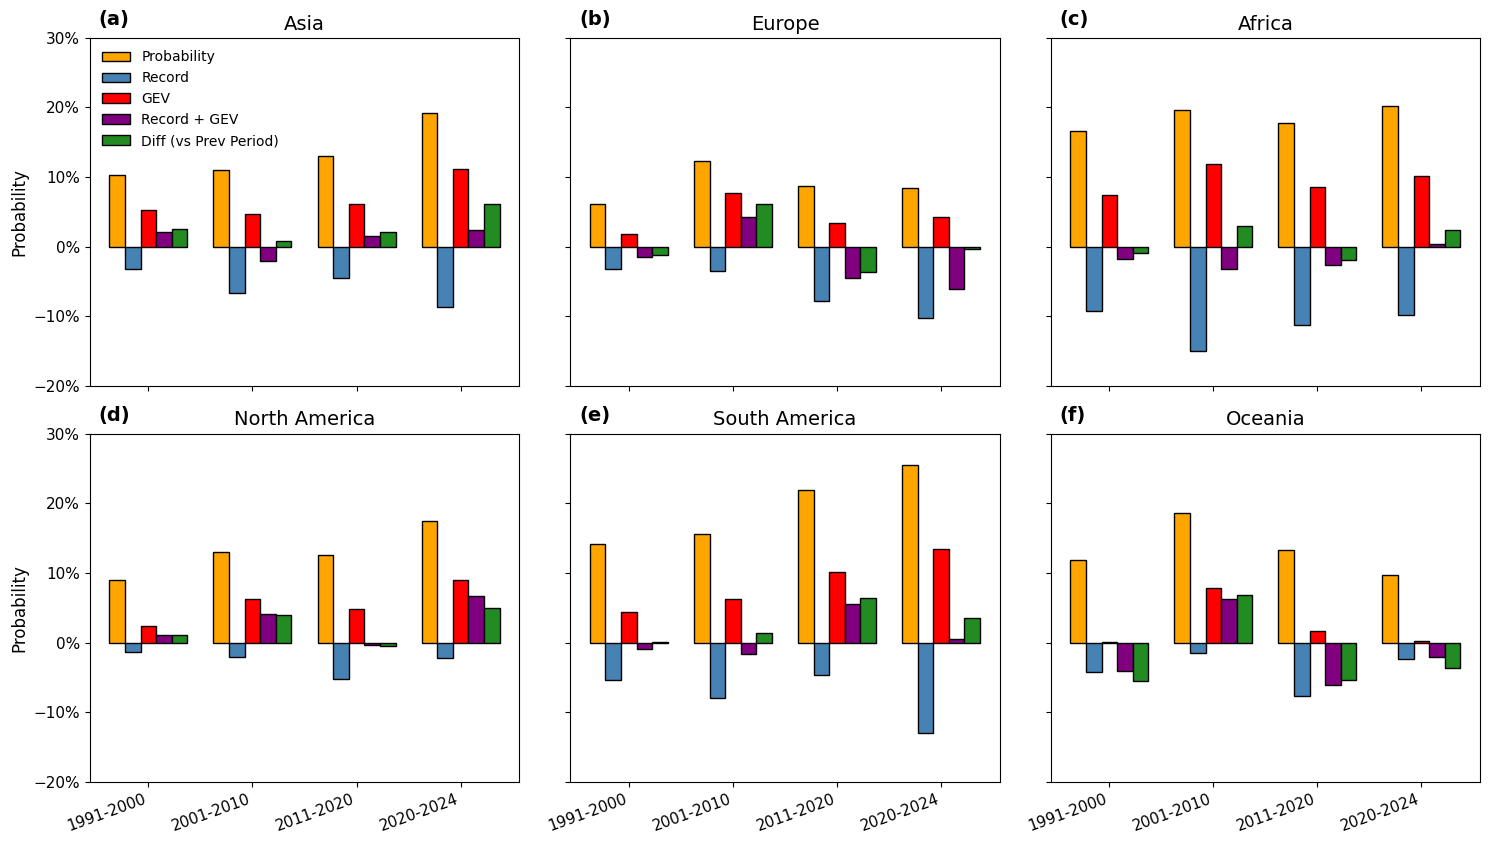

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# =========================================================
# 读取数据并提取变量
# =========================================================
ds = xr.open_dataset("record_breaking_probability_combined.nc").isel(period=slice(0, 5))

prob_raw = ds["record_breaking_probability_raw"].values
prob_end = ds["record_breaking_probability_end_year"].values
prob_fixed = ds["record_breaking_probability_fixed_period"].values

# =========================================================
# 构造原始贡献项 (5个时间段)
# =========================================================
prob_fixed_shifted = np.empty_like(prob_fixed)
prob_fixed_shifted[:, 1:] = prob_fixed[:, :-1]
prob_fixed_shifted[:, 0] = prob_raw[:, 0]

prob_diff_end = prob_raw - prob_end
prob_diff_fixed = prob_raw - prob_fixed_shifted

# 计算当前 probability 和前一个时间段的差值 (5个时间段，第一期补0)
prob_diff_time = np.zeros_like(prob_raw)
prob_diff_time[:, 1:] = prob_raw[:, 1:] - prob_raw[:, :-1]

# =========================================================
# 大洲 ID 映射字典
# =========================================================
continents = {
    "Asia": [70,108,109,110,111,112,113,114,115,116,117,118,119,120,121,
             122,123,124,125,126,127,130,133,135,136,137,138,139,140,141,
             142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,
             157,206,207,208,209,210,211,212,213,214,215,216,217,229,230,
             231,235,236],

    "Europe": [102,103,104,105,106,107,128,129,131,134,197,198,199,
               200,201,202,203,204,205,234],

    "Africa": [52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,
               69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,
               87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,132,
               225,226,227,228],

    "North America": list(range(0,32)) + [218,219,220,221,222,223,224,232],
    "South America": list(range(32,52)) + [191,192,193,194,195,196,233],
    "Oceania": [158,159,160,161,162,163,164,165,166,167,168,169]
}

# =========================================================
# 准备绘图所需的大洲平均数据 (切片截取后4个时间段)
# =========================================================
plot_names = []
plot_raw_data = []
plot_diff_end_data = []
plot_diff_fixed_data = []
plot_sum_data = []        # 新增: Record + GEV
plot_diff_time_data = []   # 新增: 与前一期差值

for name, ids in continents.items():
    plot_names.append(name)
    
    # 算好大洲均值后，直接用 [1:] 切片只保留后四个时间段
    raw_mean = np.mean(prob_raw[ids, :], axis=0)[1:]
    end_mean = np.mean(prob_diff_end[ids, :], axis=0)[1:]
    fixed_mean = np.mean(prob_diff_fixed[ids, :], axis=0)[1:]
    time_mean = np.mean(prob_diff_time[ids, :], axis=0)[1:]
    
    plot_raw_data.append(raw_mean)
    plot_diff_end_data.append(end_mean)
    plot_diff_fixed_data.append(fixed_mean)
    plot_sum_data.append(end_mean + fixed_mean)  # Record + GEV 的和
    plot_diff_time_data.append(time_mean)

# 时间轴标签同步切片，只留后四个
period_labels = ds["period"].values[1:]

# =========================================================
# 绘图（2行 3列）
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8.5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

x = np.arange(len(period_labels))
width = 0.15  # 5个柱子，将宽度设为0.15比较紧凑美观

for i, ax in enumerate(axes):

    # =====================================================
    # 五组柱子
    # =====================================================
    # 1. 原始 Probability
    ax.bar(
        x - 2 * width,
        plot_raw_data[i],
        width,
        color="orange",
        edgecolor="black",
        label="Probability"
    )

    # 2. Record 贡献
    ax.bar(
        x - width,
        plot_diff_end_data[i],
        width,
        color="steelblue",
        edgecolor="black",
        label="Record"
    )

    # 3. GEV 贡献
    ax.bar(
        x,
        plot_diff_fixed_data[i],
        width,
        color="red",
        edgecolor="black",
        label="GEV"
    )

    # 4. 新增: Record + GEV
    ax.bar(
        x + width,
        plot_sum_data[i],
        width,
        color="purple",
        edgecolor="black",
        label="Record + GEV"
    )

    # 5. 新增: 与前一期差值 (Diff)
    ax.bar(
        x + 2 * width,
        plot_diff_time_data[i],
        width,
        color="forestgreen",
        edgecolor="black",
        label="Diff (vs Prev Period)"
    )

    # =====================================================
    # 标题与子图序号 (a) 到 (f)
    # =====================================================
    ax.set_title(plot_names[i], fontsize=14)
    
    sub_label = f"({chr(97 + i)})"
    
    ax.text(
        0.02, 1.08, 
        sub_label, 
        transform=ax.transAxes, 
        fontsize=14, 
        fontweight="bold", 
        va="top", 
        ha="left"
    )

    # =====================================================
    # 坐标轴设置
    # =====================================================
    ax.set_ylim(-0.2, 0.3)
    ax.set_xticks(x)

    # 只有第二行显示 x 轴标签
    if i >= 3:
        ax.set_xticklabels(period_labels, rotation=20, ha="right")
    else:
        ax.set_xticklabels([])

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.1)) # 柱子变多，刻度稍微细化到 0.1
    ax.tick_params(axis='both', labelsize=11)

    # 只有第一列显示 y 轴标题
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=12)

# =========================================================
# 图例（展示在左上角第一个子图内）
# =========================================================
axes[0].legend(
    fontsize=10,
    loc="upper left", # 更改为左上角避免遮挡负值柱
    frameon=False
)

plt.tight_layout()

# 保存高质量 PDF
plt.savefig(
    "Fig_continents_timeseries_5bars.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

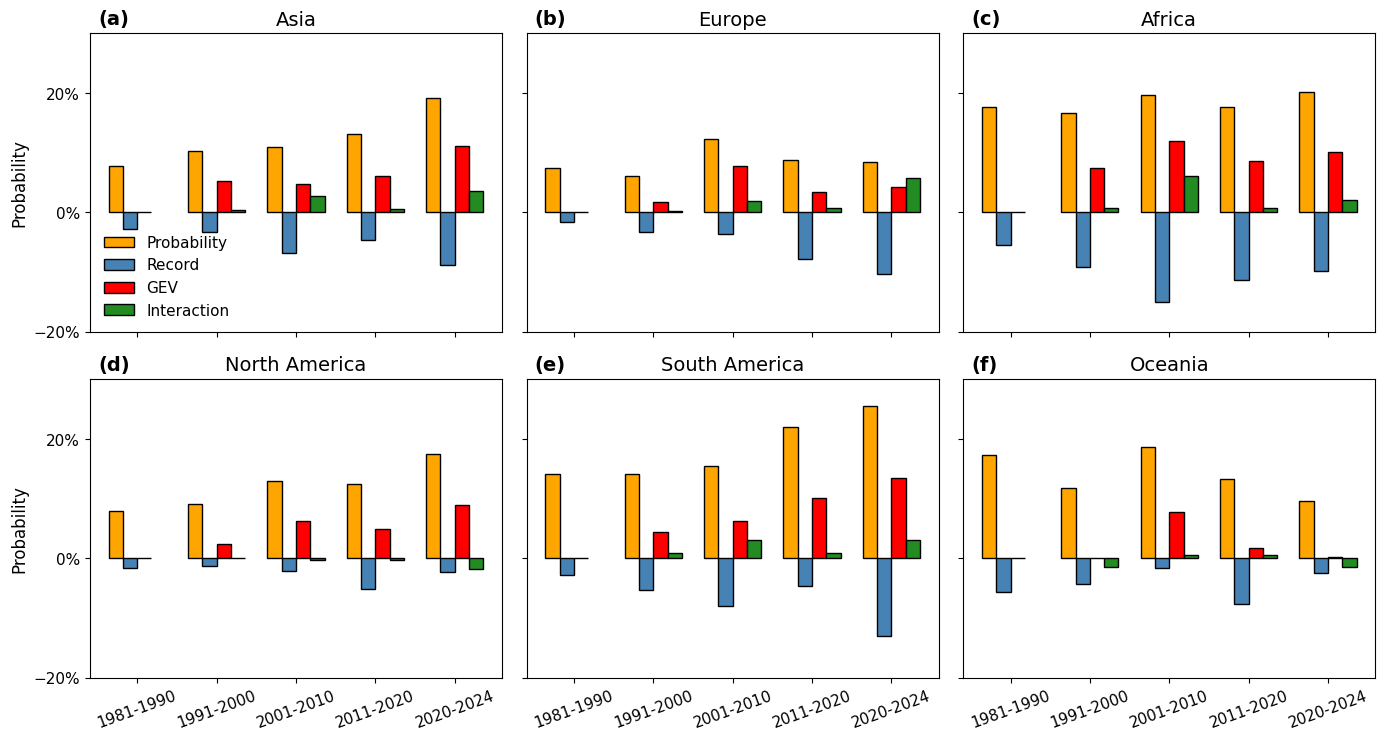

In [33]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# =========================================================
# 读取数据
# =========================================================
ds = xr.open_dataset("record_breaking_probability_combined.nc").isel(period=slice(0, 5))

# =========================================================
# 提取变量
# =========================================================
prob_raw = ds["record_breaking_probability_raw"].values
prob_end = ds["record_breaking_probability_end_year"].values
prob_fixed = ds["record_breaking_probability_fixed_period"].values

# =========================================================
# 构造贡献项与交互项
# =========================================================
prob_fixed_shifted = np.empty_like(prob_fixed)
prob_fixed_shifted[:, 1:] = prob_fixed[:, :-1]
prob_fixed_shifted[:, 0] = prob_raw[:, 0]

prob_diff_end = prob_raw - prob_end
prob_diff_fixed = prob_raw - prob_fixed_shifted

# 新增：交互项计算
# 第一个值为 NaN，后续每一列为：(prob_raw[:, j] - prob_end[:, j]) - (prob_fixed[:, j-1] - prob_raw[:, j-1])
prob_interaction = np.empty_like(prob_raw)
prob_interaction[:, 0] = np.nan
prob_interaction[:, 1:] =  (prob_fixed[:, :-1] - prob_raw[:, :-1]) - (prob_raw[:, 1:] - prob_end[:, 1:])

# =========================================================
# 大洲 ID 映射字典
# =========================================================
continents = {
    "Asia": [70,108,109,110,111,112,113,114,115,116,117,118,119,120,121,
             122,123,124,125,126,127,130,133,135,136,137,138,139,140,141,
             142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,
             157,206,207,208,209,210,211,212,213,214,215,216,217,229,230,
             231,235,236],

    "Europe": [102,103,104,105,106,107,128,129,131,134,197,198,199,
               200,201,202,203,204,205,234],

    "Africa": [52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,
               69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,
               87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,132,
               225,226,227,228],

    "North America": list(range(0,32)) + [218,219,220,221,222,223,224,232],
    "South America": list(range(32,52)) + [191,192,193,194,195,196,233],
    "Oceania": [158,159,160,161,162,163,164,165,166,167,168,169]
}

# =========================================================
# 准备绘图所需的大洲平均数据
# =========================================================
plot_names = []
plot_raw_data = []
plot_diff_end_data = []
plot_diff_fixed_data = []
plot_interaction_data = []  # 新增交互项绘图数据列表

for name, ids in continents.items():
    plot_names.append(name)
    plot_raw_data.append(np.mean(prob_raw[ids, :], axis=0))
    plot_diff_end_data.append(np.mean(prob_diff_end[ids, :], axis=0))
    plot_diff_fixed_data.append(np.mean(prob_diff_fixed[ids, :], axis=0))
    plot_interaction_data.append(np.mean(prob_interaction[ids, :], axis=0)) # 新增

period_labels = ds["period"].values

# =========================================================
# 绘图（2行 3列）
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 7.5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

x = np.arange(len(period_labels))
width = 0.18  # 略微调整柱宽以适应 4 个柱子

for i, ax in enumerate(axes):

    # =====================================================
    # 四组柱（重新计算了各自的偏移量）
    # =====================================================
    ax.bar(
        x - 1.5 * width,
        plot_raw_data[i],
        width,
        color="orange",
        edgecolor="black",
        label="Probability"
    )

    ax.bar(
        x - 0.5 * width,
        plot_diff_end_data[i],
        width,
        color="steelblue",
        edgecolor="black",
        label="Record"
    )

    ax.bar(
        x + 0.5 * width,
        plot_diff_fixed_data[i],
        width,
        color="red",
        edgecolor="black",
        label="GEV"
    )

    # 新增的第四个柱子：交互项 (第一项为 NaN 会被 matplotlib 自动忽略不画)
    ax.bar(
        x + 1.5 * width,
        plot_interaction_data[i],
        width,
        color="forestgreen",  # 选用森林绿以作区分
        edgecolor="black",
        label="Interaction"
    )

    # =====================================================
    # 标题与子图序号 (a) 到 (f)
    # =====================================================
    ax.set_title(plot_names[i], fontsize=14)
    
    sub_label = f"({chr(97 + i)})"
    
    ax.text(
        0.02, 1.08, 
        sub_label, 
        transform=ax.transAxes, 
        fontsize=14, 
        fontweight="bold", 
        va="top", 
        ha="left"
    )

    # =====================================================
    # 坐标轴设置
    # =====================================================
    ax.set_ylim(-0.2, 0.3)
    ax.set_xticks(x)

    # 只有第二行（索引 3, 4, 5）显示 x 轴标签
    if i >= 3:
        ax.set_xticklabels(period_labels, rotation=20)
    else:
        ax.set_xticklabels([])

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.tick_params(axis='both', labelsize=11)

    # 只有第一列（索引 0 和 3）显示 y 轴标题
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=12)

# =========================================================
# 图例（仅在左上角第一个大洲子图显示，更新为包含交互项）
# =========================================================
axes[0].legend(
    fontsize=11,
    loc="lower left",
    frameon=False
)

plt.tight_layout()

# 保存高质量 PDF
plt.savefig(
    "Fig_continents_timeseries_4bars.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()

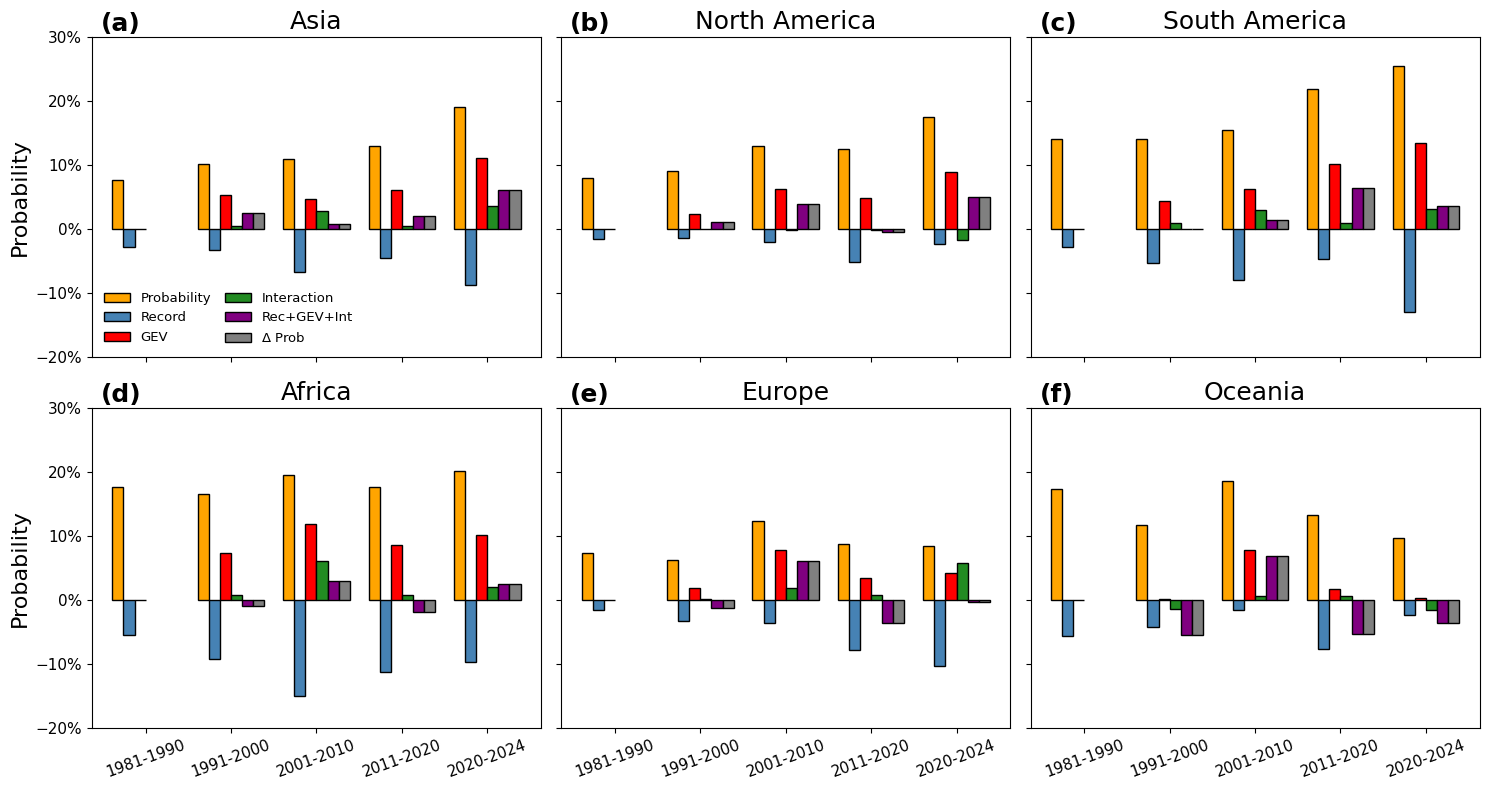

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MultipleLocator

# =========================================================
# 读取数据
# =========================================================
ds = xr.open_dataset("record_breaking_probability_combined.nc").isel(period=slice(0, 5))

# =========================================================
# 提取变量
# =========================================================
prob_raw = ds["record_breaking_probability_raw"].values
prob_end = ds["record_breaking_probability_end_year"].values
prob_fixed = ds["record_breaking_probability_fixed_period"].values

# =========================================================
# 构造贡献项与交互项
# =========================================================
prob_fixed_shifted = np.empty_like(prob_fixed)
prob_fixed_shifted[:, 1:] = prob_fixed[:, :-1]
prob_fixed_shifted[:, 0] = prob_raw[:, 0]

prob_diff_end = prob_raw - prob_end
prob_diff_fixed = prob_raw - prob_fixed_shifted

# 1. 交互项计算
prob_interaction = np.empty_like(prob_raw)
prob_interaction[:, 0] = np.nan
prob_interaction[:, 1:] = -(prob_raw[:, 1:] - prob_end[:, 1:]) + (prob_fixed[:, :-1] - prob_raw[:, :-1])

# 2. 新增：Record + GEV + Interaction (前文三项之和)
prob_sum_three = prob_diff_end + prob_diff_fixed + prob_interaction

# 3. 新增：当前时段 Probability 减去前一个时段的差值 (Delta Prob)
prob_delta_raw = np.empty_like(prob_raw)
prob_delta_raw[:, 0] = np.nan
prob_delta_raw[:, 1:] = prob_raw[:, 1:] - prob_raw[:, :-1]

# =========================================================
# 大洲 ID 映射字典
# =========================================================
continents = {
    "Asia": [70,108,109,110,111,112,113,114,115,116,117,118,119,120,121,
             122,123,124,125,126,127,130,133,135,136,137,138,139,140,141,
             142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,
             157,206,207,208,209,210,211,212,213,214,215,216,217,229,230,
             231,235,236],
    "North America": list(range(0,32)) + [218,219,220,221,222,223,224,232],
    "South America": list(range(32,52)) + [191,192,193,194,195,196,233],

    "Africa": [52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,
           69,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,
           87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,132,
           225,226,227,228],
    
    "Europe": [102,103,104,105,106,107,128,129,131,134,197,198,199,
               200,201,202,203,204,205,234],


    "Oceania": [158,159,160,161,162,163,164,165,166,167,168,169]
}

# =========================================================
# 准备绘图所需的大洲平均数据
# =========================================================
plot_names = []
plot_raw_data = []
plot_diff_end_data = []
plot_diff_fixed_data = []
plot_interaction_data = []
plot_sum_three_data = []  # 新增
plot_delta_raw_data = []  # 新增

for name, ids in continents.items():
    plot_names.append(name)
    plot_raw_data.append(np.mean(prob_raw[ids, :], axis=0))
    plot_diff_end_data.append(np.mean(prob_diff_end[ids, :], axis=0))
    plot_diff_fixed_data.append(np.mean(prob_diff_fixed[ids, :], axis=0))
    plot_interaction_data.append(np.mean(prob_interaction[ids, :], axis=0))
    plot_sum_three_data.append(np.mean(prob_sum_three[ids, :], axis=0))  # 新增
    plot_delta_raw_data.append(np.mean(prob_delta_raw[ids, :], axis=0))  # 新增

period_labels = ds["period"].values

# =========================================================
# 绘图（2行 3列）
# =========================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8),  # 稍微加宽画布以适应 6 个柱子
    sharex=True,
    sharey=True
)

axes = axes.flatten()

x = np.arange(len(period_labels))
width = 0.13  # 压缩柱子宽度，确保 6 个柱子 (总宽 0.78) 在一组 x 刻度内不拥挤

for i, ax in enumerate(axes):

    # =====================================================
    # 六组柱（重新计算了各自的偏移量中心点）
    # =====================================================
    # 1. Probability
    ax.bar(
        x - 2.5 * width,
        plot_raw_data[i],
        width,
        color="orange",
        edgecolor="black",
        label="Probability"
    )

    # 2. Record
    ax.bar(
        x - 1.5 * width,
        plot_diff_end_data[i],
        width,
        color="steelblue",
        edgecolor="black",
        label="Record"
    )

    # 3. GEV
    ax.bar(
        x - 0.5 * width,
        plot_diff_fixed_data[i],
        width,
        color="red",
        edgecolor="black",
        label="GEV"
    )

    # 4. Interaction (第一项为 NaN 会自动跳过)
    ax.bar(
        x + 0.5 * width,
        plot_interaction_data[i],
        width,
        color="forestgreen",
        edgecolor="black",
        label="Interaction"
    )

    # 5. Record + GEV + Interaction (第一项为 NaN 会自动跳过)
    ax.bar(
        x + 1.5 * width,
        plot_sum_three_data[i],
        width,
        color="purple",  # 选用紫色区分
        edgecolor="black",
        label="Rec+GEV+Int"
    )

    # 6. Delta Probability (第一项为 NaN 会自动跳过)
    ax.bar(
        x + 2.5 * width,
        plot_delta_raw_data[i],
        width,
        color="grey",  # 选用灰色区分
        edgecolor="black",
        label=r"$\Delta$ Prob"
    )

    # =====================================================
    # 标题与子图序号 (a) 到 (f)
    # =====================================================
    ax.set_title(plot_names[i], fontsize=18)
    
    sub_label = f"({chr(97 + i)})"
    
    ax.text(
        0.02, 1.08, 
        sub_label, 
        transform=ax.transAxes, 
        fontsize=18, 
        fontweight="bold", 
        va="top", 
        ha="left"
    )

    # =====================================================
    # 坐标轴设置
    # =====================================================
    ax.set_ylim(-0.2, 0.3)
    ax.set_xticks(x)

    # 只有第二行（索引 3, 4, 5）显示 x 轴标签
    if i >= 3:
        ax.set_xticklabels(period_labels, rotation=20)
    else:
        ax.set_xticklabels([])

    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.tick_params(axis='both', labelsize=11)

    # 只有第一列（索引 0 和 3）显示 y 轴标题
    if i % 3 == 0:
        ax.set_ylabel("Probability", fontsize=16)

# =========================================================
# 图例（仅在左上角第一个大洲子图显示，更新为 6 个标签）
# =========================================================
axes[0].legend(
    ncol=2,               # 分为 2 列展示
    columnspacing=1.0,    # 调整两列之间的间距，防止文字重叠
    fontsize=9.5,         # 稍微放大了字体，分两列后空间更充裕
    loc="lower left",
    frameon=False
)

plt.tight_layout()

# 保存高质量 PDF
plt.savefig(
    "Fig5_continents_decomposition_6bars.pdf",
    dpi=400,
    bbox_inches="tight"
)

plt.show()